# Analysis Code

## ET/BT Synchronization

Load cleaned ET and BT exports for one participant, check sampling rates (ET via `gaze_capture_time`, BT via `raw_timestamp`), upsample BT onto the ET `raw_timestamp` grid within each segment, merge into one dataframe, and verify the ET rate on `gaze_capture_time` after sync.

In [43]:
import re
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

In [44]:
PARTICIPANT_ID = "001"
CLEANED_DIR = Path(r"C:\Users\experiment\Desktop\cleaned_classified_P01-16_18_05_2026")
SAVE_SYNCHRONIZED = True

In [45]:
def normalize_pid(participant_id):
    pid = str(participant_id).strip()
    if not pid.isdigit():
        raise ValueError(f"Participant ID must be numeric, got: {participant_id!r}")
    return pid.zfill(3)


def load_cleaned_pair(participant_id, cleaned_dir):
    pid = normalize_pid(participant_id)
    et_path = cleaned_dir / f"clean_{pid}_ET.csv"
    bt_path = cleaned_dir / f"clean_{pid}_BT.csv"

    missing = [str(path) for path in (et_path, bt_path) if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing cleaned file(s):\n- " + "\n- ".join(missing))

    et_df = pd.read_csv(et_path, low_memory=False)
    bt_df = pd.read_csv(bt_path, low_memory=False)

    for frame in (et_df, bt_df):
        if "participant_id" in frame.columns:
            frame["participant_id"] = frame["participant_id"].astype(str).str.zfill(3)
        if "raw_timestamp" not in frame.columns:
            raise KeyError("Both cleaned files must contain 'raw_timestamp'.")
        frame["raw_timestamp"] = pd.to_numeric(frame["raw_timestamp"], errors="coerce")

    if "gaze_capture_time" not in et_df.columns:
        raise KeyError("ET file must contain 'gaze_capture_time'.")
    et_df["gaze_capture_time"] = pd.to_numeric(et_df["gaze_capture_time"], errors="coerce")

    return pid, et_path, bt_path, et_df, bt_df


def et_sampling_rate_summary(df):
    if "gaze_capture_time" not in df.columns:
        raise KeyError("ET sampling rate requires 'gaze_capture_time'.")

    t = pd.to_numeric(df["gaze_capture_time"], errors="coerce").dropna().sort_values()
    dt_ns = t.diff().dropna()
    dt_ns = dt_ns[dt_ns > 0]

    median_dt_ns = dt_ns.median()
    return pd.DataFrame(
        [
            {
                "stream": "ET",
                "time_col": "gaze_capture_time",
                "n_rows": len(t),
                "unique_timestamps": t.nunique(),
                "median_dt": median_dt_ns,
                "median_dt_unit": "ns",
                "median_sampling_rate_hz": 1e9 / median_dt_ns if pd.notna(median_dt_ns) else np.nan,
            }
        ]
    )


def bt_sampling_rate_summary(df):
    if "raw_timestamp" not in df.columns:
        raise KeyError("BT sampling rate requires 'raw_timestamp'.")

    t = pd.to_numeric(df["raw_timestamp"], errors="coerce").dropna().sort_values()
    dt_ms = t.diff().dropna()
    dt_ms = dt_ms[dt_ms > 0]

    median_dt_ms = dt_ms.median()
    return pd.DataFrame(
        [
            {
                "stream": "BT",
                "time_col": "raw_timestamp",
                "n_rows": len(t),
                "unique_timestamps": t.nunique(),
                "median_dt": median_dt_ms,
                "median_dt_unit": "ms",
                "median_sampling_rate_hz": 1000.0 / median_dt_ms if pd.notna(median_dt_ms) else np.nan,
            }
        ]
    )


def get_bt_column_groups(bt_df, group_cols=("participant_id", "condition_number", "trial_number")):
    exclude = {"raw_timestamp", *group_cols}
    discrete_passthrough = {
        "model_name",
        "model_rot_deg",
        "LeftFootArea",
        "RightFootArea",
        "source_file",
        "segment_label",
        "sampling_rate_hz",
        "dt",
        "dt_ms",
    }

    continuous_cols = []
    discrete_cols = []
    for col in bt_df.columns:
        if col in exclude:
            continue
        if col.startswith("bad_sample_") or col.startswith("is_interpolated_"):
            discrete_cols.append(col)
            continue
        if col in discrete_passthrough:
            discrete_cols.append(col)
            continue
        if pd.api.types.is_numeric_dtype(bt_df[col]):
            continuous_cols.append(col)
        else:
            discrete_cols.append(col)
    return continuous_cols, discrete_cols


def prepare_bt_segment(bt_segment, continuous_cols, discrete_cols):
    bt_seg = bt_segment.copy()
    bt_seg["raw_timestamp"] = pd.to_numeric(bt_seg["raw_timestamp"], errors="coerce")
    bt_seg = bt_seg.dropna(subset=["raw_timestamp"]).sort_values("raw_timestamp")

    agg_map = {}
    for col in continuous_cols:
        if col in bt_seg.columns:
            agg_map[col] = "mean"
    for col in discrete_cols:
        if col in bt_seg.columns:
            agg_map[col] = "first"

    if not agg_map:
        raise ValueError("No BT columns available for synchronization.")

    return (
        bt_seg.groupby("raw_timestamp", as_index=False, dropna=False)
        .agg(agg_map)
        .sort_values("raw_timestamp")
        .reset_index(drop=True)
    )


def interpolate_bt_to_et(et_segment, bt_segment, continuous_cols, discrete_cols):
    et_sync = et_segment.copy().sort_values("raw_timestamp").reset_index(drop=True)
    et_t = pd.to_numeric(et_sync["raw_timestamp"], errors="coerce").to_numpy(dtype=float)

    bt_unique = prepare_bt_segment(bt_segment, continuous_cols, discrete_cols)
    src_t = bt_unique["raw_timestamp"].to_numpy(dtype=float)

    nearest_idx = None
    nearest_support = np.zeros(len(et_sync), dtype=bool)

    if len(src_t) >= 1:
        right_idx = np.searchsorted(src_t, et_t, side="left")
        prev_idx = np.clip(right_idx - 1, 0, len(src_t) - 1)
        next_idx = np.clip(right_idx, 0, len(src_t) - 1)

        prev_t = src_t[prev_idx]
        next_t = src_t[next_idx]
        prev_dist = np.abs(et_t - prev_t)
        next_dist = np.abs(et_t - next_t)
        choose_prev = prev_dist <= next_dist
        nearest_idx = np.where(choose_prev, prev_idx, next_idx)
        nearest_support = np.isfinite(et_t) & (et_t >= src_t[0]) & (et_t <= src_t[-1])

    for col in continuous_cols:
        out_col = f"bt_{col}"
        if col not in bt_unique.columns:
            et_sync[out_col] = np.nan
            continue

        src_v = pd.to_numeric(bt_unique[col], errors="coerce").to_numpy(dtype=float)
        valid = np.isfinite(src_t) & np.isfinite(src_v)
        if valid.sum() < 2:
            et_sync[out_col] = np.nan
            continue

        t_valid = src_t[valid]
        v_valid = src_v[valid]
        within = np.isfinite(et_t) & (et_t >= t_valid[0]) & (et_t <= t_valid[-1])

        interp_values = np.full(len(et_sync), np.nan, dtype=float)
        interp_values[within] = np.interp(et_t[within], t_valid, v_valid)
        et_sync[out_col] = interp_values

    for col in discrete_cols:
        out_col = f"bt_{col}"
        if col not in bt_unique.columns:
            et_sync[out_col] = np.nan
            continue

        src_series = bt_unique[col]
        if pd.api.types.is_numeric_dtype(src_series):
            carried = np.full(len(et_sync), np.nan, dtype=float)
            if nearest_idx is not None and nearest_support.any():
                src_values = pd.to_numeric(src_series, errors="coerce").to_numpy(dtype=float)
                carried[nearest_support] = src_values[nearest_idx[nearest_support]]
            et_sync[out_col] = carried
        else:
            carried = np.full(len(et_sync), np.nan, dtype=object)
            if nearest_idx is not None and nearest_support.any():
                src_values = src_series.astype(object).to_numpy()
                carried[nearest_support] = src_values[nearest_idx[nearest_support]]
            et_sync[out_col] = carried

    return et_sync


def synchronize_et_bt(et_df, bt_df, group_cols=("participant_id", "condition_number", "trial_number")):
    group_cols = list(group_cols)
    missing = [col for col in group_cols if col not in et_df.columns or col not in bt_df.columns]
    if missing:
        raise KeyError(f"Missing grouping column(s) in ET or BT data: {missing}")

    continuous_cols, discrete_cols = get_bt_column_groups(bt_df, group_cols=group_cols)
    bt_groups = {
        key if isinstance(key, tuple) else (key,): sub.copy()
        for key, sub in bt_df.groupby(group_cols, sort=True, dropna=False)
    }

    synced_segments = []
    empty_bt = bt_df.iloc[0:0].copy()

    for key, et_segment in et_df.groupby(group_cols, sort=True, dropna=False):
        key = key if isinstance(key, tuple) else (key,)
        bt_segment = bt_groups.get(key, empty_bt)
        synced_segments.append(
            interpolate_bt_to_et(et_segment, bt_segment, continuous_cols, discrete_cols)
        )

    return pd.concat(synced_segments, axis=0, ignore_index=True)


def build_synchronized_dataframe(participant_id, cleaned_dir):
    pid, et_path, bt_path, et_df, bt_df = load_cleaned_pair(participant_id, cleaned_dir)

    et_pre = et_sampling_rate_summary(et_df)
    bt_pre = bt_sampling_rate_summary(bt_df)

    sync_df = synchronize_et_bt(et_df, bt_df)
    et_post = et_sampling_rate_summary(sync_df)

    et_pre_hz = et_pre["median_sampling_rate_hz"].iloc[0]
    et_post_hz = et_post["median_sampling_rate_hz"].iloc[0]

    rate_report = pd.DataFrame(
        [
            {
                "stage": "pre_sync",
                "stream": "ET",
                "time_col": "gaze_capture_time",
                "median_sampling_rate_hz": et_pre_hz,
            },
            {
                "stage": "pre_sync",
                "stream": "BT",
                "time_col": "raw_timestamp",
                "median_sampling_rate_hz": bt_pre["median_sampling_rate_hz"].iloc[0],
            },
            {
                "stage": "post_sync",
                "stream": "ET",
                "time_col": "gaze_capture_time",
                "median_sampling_rate_hz": et_post_hz,
            },
        ]
    )
    rate_report["rate_diff_from_et_pre_hz"] = rate_report["median_sampling_rate_hz"] - et_pre_hz

    meta = {
        "pid": pid,
        "et_path": et_path,
        "bt_path": bt_path,
        "et_shape": et_df.shape,
        "bt_shape": bt_df.shape,
        "sync_shape": sync_df.shape,
        "et_pre_hz": et_pre_hz,
        "et_post_hz": et_post_hz,
    }

    return sync_df, rate_report, meta

In [46]:
UI_BUTTONS = {
    "ContinueButton", "NextItemButton", "RotationButton", "ValidationButtonLeft",
    "ValidationButtonRight", "QuestionButton1", "QuestionButton2", "QuestionButton3",
    "QuestionButton4", "QuestionButton5", "QuestionButton6", "QuestionButton7",
    "ImageFixationCross"
}
WORKSPACE = {"WorkBack", "WorkLeft", "WorkRight"}
ENVIRONMENT = {"Lamp_Front_Left"}
DISPLAY_SURFACES = {"ModelFront", "ResourceFront", "Model_plate"}
LEGO_PREFABS = {
    "Lego_1x3_Green", "Lego_1x3_Pink", "Lego_1x3_Pink (1)",
    "Lego_2x2_Blue_Dis", "Lego_2x2_Orange", "Lego_3x2_Orange_Dis",
    "Lego_4x2_Blue", "Lego_4x2_Green", "Lego_4x2_Green (1)",
    "Lego_4x2_Orange", "Lego_4x2_Pink_Dis"
}


def get_object_group(name):
    if pd.isna(name):
        return np.nan

    name = str(name)

    if name == "model_desk_base":
        return "model_desk_base"
    if name == "resource_desk_base":
        return "resource_desk_base"
    if name == "work_desk_base":
        return "work_desk_base"

    m = re.search(r"_(res|temp|dis)_(\d+)", name)
    if m:
        return f"{m.group(1)}_{m.group(2)}"

    if re.match(r"board_stud_top_\d+", name) or name == "Lego_Board_10x10" or "Board" in name:
        return "board"

    if re.match(r"Wall_", name) or name in {"Ceiling", "Floor", "PlaneLeft", "PlaneRight"}:
        return "walls"

    if name in UI_BUTTONS:
        return "ui"

    if name in WORKSPACE:
        return "workspace"

    if name in DISPLAY_SURFACES:
        return "display_surface"

    if name in LEGO_PREFABS:
        return "lego_prefab"

    if name in ENVIRONMENT:
        return "environment"

    return f"unknown_{name}"


def _prepare_sequence_frame(sync_df):
    df = sync_df.copy()
    required_cols = [
        "participant_id", "condition_number", "trial_number", "gaze_capture_time", "velocity_category",
        "hit_obj_name", "bt_LeftHand_grabbed_name", "bt_RightHand_grabbed_name",
        "bt_LeftFootArea", "bt_RightFootArea"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns for sequence extraction: {missing}")

    df["participant_id"] = df["participant_id"].astype(str).str.zfill(3)
    df["gaze_capture_time"] = pd.to_numeric(df["gaze_capture_time"], errors="coerce")
    df = df.dropna(subset=["gaze_capture_time"]).copy()
    df["time_ms"] = df["gaze_capture_time"] / 1e6
    df = df.sort_values(["participant_id", "condition_number", "trial_number", "gaze_capture_time"]).reset_index(drop=True)
    df["hit_obj_group"] = df["hit_obj_name"].apply(get_object_group)
    return df


def check_fixation_group_dominance(df, dominance_threshold=0.50, min_duration_ms=50, group_col="hit_obj_group"):
    block_cols = ["participant_id", "condition_number", "trial_number"]
    df = df.copy().sort_values(block_cols + ["gaze_capture_time"])

    df["run_id"] = (
        (df["velocity_category"] != df["velocity_category"].shift())
        | (df["participant_id"] != df["participant_id"].shift())
        | (df["condition_number"] != df["condition_number"].shift())
        | (df["trial_number"] != df["trial_number"].shift())
    ).cumsum()

    results = []
    fixation_runs = df[df["velocity_category"] == "fixation"].groupby("run_id", sort=True)

    for run_id, grp in fixation_runs:
        start_time_ms = grp["time_ms"].min()
        end_time_ms = grp["time_ms"].max()
        duration_ms = end_time_ms - start_time_ms
        if duration_ms < min_duration_ms:
            continue

        looked_groups = grp[group_col].dropna()
        n_named = len(looked_groups)
        if n_named == 0:
            dominant_group = None
            dominance = np.nan
            stable = False
            n_unique_groups = 0
        else:
            counts = looked_groups.value_counts()
            dominant_group = counts.index[0]
            dominance = counts.iloc[0] / n_named
            stable = dominance >= dominance_threshold
            n_unique_groups = looked_groups.nunique()

        results.append(
            {
                "run_id": run_id,
                "participant_id": grp["participant_id"].iloc[0],
                "condition_number": grp["condition_number"].iloc[0],
                "trial_number": grp["trial_number"].iloc[0],
                "start_time_ms": start_time_ms,
                "end_time_ms": end_time_ms,
                "duration_ms": duration_ms,
                "n_samples": len(grp),
                "dominant_group": dominant_group,
                "dominance_ratio": dominance,
                "n_unique_groups": n_unique_groups,
                "stable": stable,
            }
        )

    return pd.DataFrame(results)


def is_res_or_temp_group(group_name):
    if pd.isna(group_name):
        return False
    return bool(re.match(r"^(res|temp)_\d+$", str(group_name)))


def get_fixation_group_type(group_name):
    if pd.isna(group_name):
        return None
    m = re.match(r"^(res|temp)_\d+$", str(group_name))
    if not m:
        return None
    return m.group(1)


def is_brick_name(name):
    if pd.isna(name):
        return False
    return bool(re.match(r"^brick_.*_(res|temp|dis)_\d+$", str(name)))


def _get_grab_pos_cols(hand):
    return (
        f"bt_{hand}Grab_obj_pos_x",
        f"bt_{hand}Grab_obj_pos_y",
        f"bt_{hand}Grab_obj_pos_z",
    )


def _infer_resource_bounds(df):
    mask_resource_stance = (df["bt_LeftFootArea"] == "Resource") | (df["bt_RightFootArea"] == "Resource")
    pos_cols = [
        "bt_LeftGrab_obj_pos_x", "bt_LeftGrab_obj_pos_y", "bt_LeftGrab_obj_pos_z",
        "bt_RightGrab_obj_pos_x", "bt_RightGrab_obj_pos_y", "bt_RightGrab_obj_pos_z",
    ]

    samples = []
    for hand in ("Left", "Right"):
        x_col, y_col, z_col = _get_grab_pos_cols(hand)
        if all(c in df.columns for c in (x_col, y_col, z_col)):
            tmp = df.loc[mask_resource_stance, [x_col, y_col, z_col]].copy()
            tmp.columns = ["x", "y", "z"]
            samples.append(tmp)

    if not samples:
        return None

    pos = pd.concat(samples, axis=0, ignore_index=True).dropna()
    if pos.empty:
        return None

    q_low = pos.quantile(0.05)
    q_high = pos.quantile(0.95)
    pad = 0.05
    return {
        "x_min": float(q_low["x"] - pad),
        "x_max": float(q_high["x"] + pad),
        "y_min": float(q_low["y"] - pad),
        "y_max": float(q_high["y"] + pad),
        "z_min": float(q_low["z"] - pad),
        "z_max": float(q_high["z"] + pad),
    }


def _classify_grab_start_area(row, bounds):
    if bounds is None:
        return "Unknown"

    x, y, z = row["grab_start_pos_x"], row["grab_start_pos_y"], row["grab_start_pos_z"]
    if pd.isna(x) or pd.isna(y) or pd.isna(z):
        return "Unknown"

    inside = (
        (bounds["x_min"] <= x <= bounds["x_max"])
        and (bounds["y_min"] <= y <= bounds["y_max"])
        and (bounds["z_min"] <= z <= bounds["z_max"])
    )
    return "Resource" if inside else "NonResource"


def detect_grab_events(df):
    block_cols = ["participant_id", "condition_number", "trial_number"]
    events = []
    bounds = _infer_resource_bounds(df)

    for _, grp in df.groupby(block_cols, sort=True, dropna=False):
        grp = grp.sort_values("gaze_capture_time").copy()

        for hand in ("Left", "Right"):
            grab_col = f"bt_{hand}Hand_grabbed_name"
            x_col, y_col, z_col = _get_grab_pos_cols(hand)
            has_pos = all(c in grp.columns for c in (x_col, y_col, z_col))

            values = grp[grab_col].astype(object).to_numpy()
            times_ms = grp["time_ms"].to_numpy()
            times_ns = grp["gaze_capture_time"].to_numpy()
            pos_x = grp[x_col].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_y = grp[y_col].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_z = grp[z_col].to_numpy() if has_pos else np.full(len(grp), np.nan)

            i = 0
            while i < len(grp):
                name = values[i]
                if not is_brick_name(name):
                    i += 1
                    continue

                start_i = i
                while i + 1 < len(grp) and values[i + 1] == name:
                    i += 1
                end_i = i

                events.append(
                    {
                        "participant_id": grp["participant_id"].iloc[0],
                        "condition_number": grp["condition_number"].iloc[0],
                        "trial_number": grp["trial_number"].iloc[0],
                        "hand": hand,
                        "grabbed_name": name,
                        "grab_start_time_ms": times_ms[start_i],
                        "grab_start_time_ns": times_ns[start_i],
                        "grab_end_time_ms": times_ms[end_i],
                        "grab_end_time_ns": times_ns[end_i],
                        "grab_start_pos_x": pos_x[start_i],
                        "grab_start_pos_y": pos_y[start_i],
                        "grab_start_pos_z": pos_z[start_i],
                        "start_row_idx": int(start_i),
                        "end_row_idx": int(end_i),
                    }
                )
                i += 1

    if not events:
        return pd.DataFrame(columns=[
            "participant_id", "condition_number", "trial_number", "hand", "grabbed_name",
            "grab_start_time_ms", "grab_start_time_ns", "grab_end_time_ms", "grab_end_time_ns",
            "grab_start_pos_x", "grab_start_pos_y", "grab_start_pos_z",
            "start_row_idx", "end_row_idx", "grab_start_area",
            "grab_idx_in_trial", "prev_grab_start_time_ms", "prev_grab_start_time_ns"
        ])

    out = pd.DataFrame(events).sort_values(
        ["participant_id", "condition_number", "trial_number", "grab_start_time_ns"]
    ).reset_index(drop=True)

    out["grab_start_area"] = out.apply(lambda r: _classify_grab_start_area(r, bounds), axis=1)

    out["grab_idx_in_trial"] = out.groupby(block_cols).cumcount() + 1
    out["prev_grab_start_time_ms"] = out.groupby(block_cols)["grab_start_time_ms"].shift(1)
    out["prev_grab_start_time_ns"] = out.groupby(block_cols)["grab_start_time_ns"].shift(1)
    return out


def build_grab_fixation_outputs(sync_df, dominance_threshold=0.50, min_duration_ms=50):
    df = _prepare_sequence_frame(sync_df)

    fixation_runs = check_fixation_group_dominance(
        df,
        dominance_threshold=dominance_threshold,
        min_duration_ms=min_duration_ms,
        group_col="hit_obj_group",
    )
    fixation_candidates = fixation_runs[
        fixation_runs["stable"] & fixation_runs["dominant_group"].apply(is_res_or_temp_group)
    ].copy()
    fixation_candidates["fixation_group_type"] = fixation_candidates["dominant_group"].apply(get_fixation_group_type)

    all_grab_episodes = detect_grab_events(df)
    grab_events = all_grab_episodes[all_grab_episodes["grab_start_area"] == "Resource"].copy()

    events_out = []
    for _, grab in grab_events.iterrows():
        key = (grab["participant_id"], grab["condition_number"], grab["trial_number"])
        block_fix = fixation_candidates[
            (fixation_candidates["participant_id"] == key[0])
            & (fixation_candidates["condition_number"] == key[1])
            & (fixation_candidates["trial_number"] == key[2])
        ]

        curr_t = grab["grab_start_time_ms"]
        prev_t = grab["prev_grab_start_time_ms"]
        if pd.isna(prev_t):
            in_window = (block_fix["end_time_ms"] <= curr_t)
        else:
            in_window = (block_fix["end_time_ms"] > prev_t) & (block_fix["end_time_ms"] <= curr_t)

        for _, fx in block_fix[in_window].iterrows():
            events_out.append(
                {
                    "participant_id": grab["participant_id"],
                    "condition_number": grab["condition_number"],
                    "trial_number": grab["trial_number"],
                    "grab_idx_in_trial": grab["grab_idx_in_trial"],
                    "hand": grab["hand"],
                    "grabbed_name": grab["grabbed_name"],
                    "grab_start_area": grab["grab_start_area"],
                    "grab_start_pos_x": grab["grab_start_pos_x"],
                    "grab_start_pos_y": grab["grab_start_pos_y"],
                    "grab_start_pos_z": grab["grab_start_pos_z"],
                    "prev_grab_start_time_ms": prev_t,
                    "curr_grab_start_time_ms": curr_t,
                    "grab_end_time_ms": grab["grab_end_time_ms"],
                    "run_id": fx["run_id"],
                    "fixation_start_time_ms": fx["start_time_ms"],
                    "fixation_end_time_ms": fx["end_time_ms"],
                    "fixation_duration_ms": fx["duration_ms"],
                    "dominant_group": fx["dominant_group"],
                    "fixation_group_type": fx["fixation_group_type"],
                    "dominance_ratio": fx["dominance_ratio"],
                    "n_samples": fx["n_samples"],
                }
            )

    grab_fixation_events_df = pd.DataFrame(events_out)

    summary_base = grab_events[[
        "participant_id", "condition_number", "trial_number", "grab_idx_in_trial",
        "hand", "grabbed_name", "grab_start_area",
        "grab_start_pos_x", "grab_start_pos_y", "grab_start_pos_z",
        "prev_grab_start_time_ms", "grab_start_time_ms", "grab_end_time_ms"
    ]].rename(columns={"grab_start_time_ms": "curr_grab_start_time_ms"}).copy()

    if grab_fixation_events_df.empty:
        grab_fixation_summary_df = summary_base.copy()
        grab_fixation_summary_df["n_fix_res"] = 0
        grab_fixation_summary_df["n_fix_temp"] = 0
        grab_fixation_summary_df["n_fix_total"] = 0
        grab_fixation_summary_df["dur_fix_res_ms"] = 0.0
        grab_fixation_summary_df["dur_fix_temp_ms"] = 0.0
        grab_fixation_summary_df["dur_fix_total_ms"] = 0.0
        grab_fixation_summary_df["res_share"] = np.nan
        grab_fixation_summary_df["temp_share"] = np.nan
    else:
        key_cols = ["participant_id", "condition_number", "trial_number", "grab_idx_in_trial"]

        counts = (
            grab_fixation_events_df
            .pivot_table(index=key_cols, columns="fixation_group_type", values="run_id", aggfunc="count", fill_value=0)
            .rename(columns={"res": "n_fix_res", "temp": "n_fix_temp"})
            .reset_index()
        )

        durs = (
            grab_fixation_events_df
            .pivot_table(index=key_cols, columns="fixation_group_type", values="fixation_duration_ms", aggfunc="sum", fill_value=0.0)
            .rename(columns={"res": "dur_fix_res_ms", "temp": "dur_fix_temp_ms"})
            .reset_index()
        )

        grab_fixation_summary_df = summary_base.merge(counts, on=key_cols, how="left").merge(durs, on=key_cols, how="left")
        for col, default in [
            ("n_fix_res", 0), ("n_fix_temp", 0), ("dur_fix_res_ms", 0.0), ("dur_fix_temp_ms", 0.0)
        ]:
            if col not in grab_fixation_summary_df.columns:
                grab_fixation_summary_df[col] = default
            else:
                grab_fixation_summary_df[col] = grab_fixation_summary_df[col].fillna(default)

        grab_fixation_summary_df["n_fix_total"] = grab_fixation_summary_df["n_fix_res"] + grab_fixation_summary_df["n_fix_temp"]
        grab_fixation_summary_df["dur_fix_total_ms"] = grab_fixation_summary_df["dur_fix_res_ms"] + grab_fixation_summary_df["dur_fix_temp_ms"]

        dur_total = grab_fixation_summary_df["dur_fix_total_ms"].replace(0, np.nan)
        grab_fixation_summary_df["res_share"] = grab_fixation_summary_df["dur_fix_res_ms"] / dur_total
        grab_fixation_summary_df["temp_share"] = grab_fixation_summary_df["dur_fix_temp_ms"] / dur_total

    qc = {
        "n_rows": len(df),
        "n_fixation_runs": len(fixation_runs),
        "n_fixation_candidates_res_temp": len(fixation_candidates),
        "n_grab_episodes_all": len(all_grab_episodes),
        "n_grab_episodes_resource_start": len(grab_events),
        "n_grabs_with_fixations": int((grab_fixation_summary_df["n_fix_total"] > 0).sum()) if not grab_fixation_summary_df.empty else 0,
        "n_grabs_without_fixations": int((grab_fixation_summary_df["n_fix_total"] == 0).sum()) if not grab_fixation_summary_df.empty else 0,
        "n_event_rows": len(grab_fixation_events_df),
    }

    return {
        "prepared_df": df,
        "fixation_runs": fixation_runs,
        "fixation_candidates": fixation_candidates,
        "all_grab_episodes": all_grab_episodes,
        "grab_events": grab_events,
        "grab_fixation_events_df": grab_fixation_events_df,
        "grab_fixation_summary_df": grab_fixation_summary_df,
        "qc": qc,
    }


def extract_sequences_for_participant(participant_id, cleaned_dir, dominance_threshold=0.50, min_duration_ms=50):
    sync_df, rate_report, meta = build_synchronized_dataframe(participant_id, cleaned_dir)
    result = build_grab_fixation_outputs(
        sync_df,
        dominance_threshold=dominance_threshold,
        min_duration_ms=min_duration_ms,
    )
    result["sync_df"] = sync_df
    result["rate_report"] = rate_report
    result["meta"] = meta
    return result


def extract_sequences_for_sync_files(sync_paths, dominance_threshold=0.50, min_duration_ms=50):
    all_events = []
    all_summary = []
    all_qc = []

    for sync_path in sync_paths:
        sync_df = pd.read_csv(sync_path, low_memory=False)
        out = build_grab_fixation_outputs(
            sync_df,
            dominance_threshold=dominance_threshold,
            min_duration_ms=min_duration_ms,
        )

        events = out["grab_fixation_events_df"].copy()
        summary = out["grab_fixation_summary_df"].copy()

        if not events.empty:
            events["source_sync_file"] = Path(sync_path).name
            all_events.append(events)

        if not summary.empty:
            summary["source_sync_file"] = Path(sync_path).name
            all_summary.append(summary)

        qc_row = out["qc"].copy()
        qc_row["source_sync_file"] = Path(sync_path).name
        all_qc.append(qc_row)

    events_all = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
    summary_all = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()
    qc_all = pd.DataFrame(all_qc)
    return events_all, summary_all, qc_all

In [47]:
sync_df, rate_report, meta = build_synchronized_dataframe(PARTICIPANT_ID, CLEANED_DIR)
pid = meta["pid"]

print(f"Participant: {pid}")
print(f"ET file: {meta['et_path'].name}")
print(f"BT file: {meta['bt_path'].name}")
print(f"ET shape: {meta['et_shape']} | BT shape: {meta['bt_shape']}")
print()
print("Pre-sync sampling rates:")
print(f"  ET (gaze_capture_time): {meta['et_pre_hz']:.2f} Hz")
print(f"  BT (raw_timestamp):     {rate_report.loc[1, 'median_sampling_rate_hz']:.2f} Hz")
print()
print(f"Synchronized shape: {meta['sync_shape']}")
print()
print(f"Post-sync ET rate (gaze_capture_time): {meta['et_post_hz']:.2f} Hz")
rate_diff = meta["et_post_hz"] - meta["et_pre_hz"]
print(f"Rate difference (post - pre): {rate_diff:.4f} Hz")
print()
display(rate_report)
display(sync_df.head())

assert abs(rate_diff) < 0.1, (
    f"ET gaze_capture_time sampling rate changed after sync: "
    f"pre={meta['et_pre_hz']:.4f} Hz, post={meta['et_post_hz']:.4f} Hz"
)

Participant: 001
ET file: clean_001_ET.csv
BT file: clean_001_BT.csv
ET shape: (354382, 73) | BT shape: (164974, 79)

Pre-sync sampling rates:
  ET (gaze_capture_time): 199.97 Hz
  BT (raw_timestamp):     90.91 Hz

Synchronized shape: (354382, 148)

Post-sync ET rate (gaze_capture_time): 199.97 Hz
Rate difference (post - pre): 0.0000 Hz



,stage,stream,time_col,median_sampling_rate_hz,rate_diff_from_et_pre_hz
0,pre_sync,ET,gaze_capture_time,199.972004,0.000000
1,pre_sync,BT,raw_timestamp,90.909091,-109.062913
2,post_sync,ET,gaze_capture_time,199.972004,0.000000


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bt_is_interpolated_LeftFoot,bt_bad_sample_Waist,bt_is_interpolated_Waist,bt_bad_sample_LeftHand,bt_is_interpolated_LeftHand,bt_bad_sample_RightHand,bt_is_interpolated_RightHand,bt_segment_label,bt_dt,bt_sampling_rate_hz
0,1000001886734534500,1778060668925,996.9191,2.0,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,NaN,NaN
1,1000001886739535200,1778060668925,996.9191,2.0,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,NaN,NaN
2,1000001886744543200,1778060668934,996.9284,2.0,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.0
3,1000001886749543300,1778060668934,996.9284,2.0,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.0
4,1000001886754542400,1778060668945,996.9396,2.0,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.0


In [48]:
sync_df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bt_is_interpolated_LeftFoot,bt_bad_sample_Waist,bt_is_interpolated_Waist,bt_bad_sample_LeftHand,bt_is_interpolated_LeftHand,bt_bad_sample_RightHand,bt_is_interpolated_RightHand,bt_segment_label,bt_dt,bt_sampling_rate_hz
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,NaN,NaN
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,NaN,NaN
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.000000
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.000000
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C3_T6,172.0,5.813953
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C3_T6,172.0,5.813953
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C3_T6,172.0,5.813953
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C3_T6,172.0,5.813953


In [49]:
sync_output_path = CLEANED_DIR / f"synchronized_{pid}_ET_BT.csv"

if SAVE_SYNCHRONIZED:
    sync_df.to_csv(sync_output_path, index=False)
    print(f"Wrote synchronized file: {sync_output_path}")
else:
    print("Set SAVE_SYNCHRONIZED = True to write:")
    print(sync_output_path)

Wrote synchronized file: C:\Users\experiment\Desktop\cleaned_classified_P01-16_18_05_2026\synchronized_001_ET_BT.csv


## Grab-Split Fixation Extraction

This section splits the trial timeline by grab events.
For each grab, it collects stable fixations on `res_*` and `temp_*` brick groups in the window from the previous grab to the current grab.

In [50]:
grab_result = build_grab_fixation_outputs(
    sync_df,
    dominance_threshold=0.50,
    min_duration_ms=50,
)

grab_fixation_events_df = grab_result["grab_fixation_events_df"]
grab_fixation_summary_df = grab_result["grab_fixation_summary_df"]
fixation_candidates_df = grab_result["fixation_candidates"]
grab_events_df = grab_result["grab_events"]
qc = grab_result["qc"]

print("Grab-split fixation QC:")
for k, v in qc.items():
    print(f"  {k}: {v}")

print("\nTop dominant fixation groups (res/temp candidates):")
if fixation_candidates_df.empty:
    print("  No res/temp fixation candidates found.")
else:
    display(fixation_candidates_df["dominant_group"].value_counts().head(10).to_frame("count"))

print("\nTop grabbed objects:")
if grab_events_df.empty:
    print("  No grab events found.")
else:
    display(grab_events_df["grabbed_name"].value_counts().head(10).to_frame("count"))

print("\nPer-grab summary (head):")
display(grab_fixation_summary_df.head(20))

print("\nPer-grab fixation events (head):")
display(grab_fixation_events_df.head(20))

print("\nDistribution of fixation counts per grab:")
if grab_fixation_summary_df.empty:
    print("  No grabs available.")
else:
    display(grab_fixation_summary_df["n_fix_total"].value_counts().sort_index().to_frame("n_grabs"))

Grab-split fixation QC:
  n_rows: 354382
  n_fixation_runs: 4190
  n_fixation_candidates_res_temp: 2904
  n_grab_episodes_all: 503
  n_grab_episodes_resource_start: 102
  n_grabs_with_fixations: 86
  n_grabs_without_fixations: 16
  n_event_rows: 845

Top dominant fixation groups (res/temp candidates):


,count
dominant_group,
res_071,60
res_034,54
res_033,47
temp_034,46
res_068,41
res_043,38
temp_044,35
temp_094,35
res_116,33



Top grabbed objects:


,count
grabbed_name,
brick_2x2_green_res_022,3
brick_2x2_pink_res_023,3
brick_2x4_blue_res_068,2
brick_2x4_pink_res_106,2
brick_2x4_pink_res_111,2
brick_2x2_pink_res_058,2
brick_2x4_green_res_042,2
brick_2x4_yellow_res_084,2
brick_2x2_green_res_110,2



Per-grab summary (head):


,participant_id,condition_number,trial_number,grab_idx_in_trial,hand,grabbed_name,grab_start_area,grab_start_pos_x,grab_start_pos_y,grab_start_pos_z,...,curr_grab_start_time_ms,grab_end_time_ms,n_fix_res,n_fix_temp,dur_fix_res_ms,dur_fix_temp_ms,n_fix_total,dur_fix_total_ms,res_share,temp_share
0,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,5.0,3.0,1126.129517,740.094238,8.0,1866.223755,0.603427,0.396573
1,001,1,1,9,Right,brick_2x2_green_res_018,Resource,0.045235,0.971703,-1.715954,...,1.000002e+12,1.000002e+12,5.0,0.0,2145.280518,0.000000,5.0,2145.280518,1.000000,0.000000
2,001,1,1,10,Left,brick_2x2_pink_res_017,Resource,-0.058444,0.911902,-1.597295,...,1.000002e+12,1.000002e+12,3.0,0.0,1310.166626,0.000000,3.0,1310.166626,1.000000,0.000000
3,001,1,2,2,Right,brick_2x2_green_res_005,Resource,-0.074398,0.971703,-1.771740,...,1.000002e+12,1.000002e+12,5.0,0.0,675.062988,0.000000,5.0,675.062988,1.000000,0.000000
4,001,1,2,4,Left,brick_2x2_yellow_dis_004,Resource,-0.239175,0.994803,-1.678656,...,1.000002e+12,1.000002e+12,1.0,0.0,495.060913,0.000000,1.0,495.060913,1.000000,0.000000
5,001,1,2,5,Left,brick_2x2_yellow_dis_004,Resource,-0.257826,0.971703,-1.683277,...,1.000002e+12,1.000002e+12,1.0,0.0,620.088867,0.000000,1.0,620.088867,1.000000,0.000000
6,001,1,2,6,Left,brick_2x2_pink_res_007,Resource,-0.118349,0.883366,-1.501915,...,1.000002e+12,1.000002e+12,2.0,0.0,1005.127686,0.000000,2.0,1005.127686,1.000000,0.000000
7,001,1,3,1,Right,brick_2x4_green_res_067,Resource,-0.016963,0.890727,-1.399940,...,1.000002e+12,1.000002e+12,3.0,3.0,456.052612,745.087402,6.0,1201.140015,0.379683,0.620317
8,001,1,3,2,Left,brick_1x3_yellow_res_069,Resource,0.111769,0.994803,-1.442186,...,1.000002e+12,1.000002e+12,1.0,0.0,230.029297,0.000000,1.0,230.029297,1.000000,0.000000
9,001,1,3,4,Right,brick_2x4_blue_res_068,Resource,-0.147370,0.883366,-1.581651,...,1.000002e+12,1.000002e+12,13.0,2.0,4200.521606,165.011475,15.0,4365.533081,0.962201,0.037799



Per-grab fixation events (head):


,participant_id,condition_number,trial_number,grab_idx_in_trial,hand,grabbed_name,grab_start_area,grab_start_pos_x,grab_start_pos_y,grab_start_pos_z,...,curr_grab_start_time_ms,grab_end_time_ms,run_id,fixation_start_time_ms,fixation_end_time_ms,fixation_duration_ms,dominant_group,fixation_group_type,dominance_ratio,n_samples
0,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,40,1.000002e+12,1.000002e+12,580.066772,temp_020,temp,0.700855,117
1,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,42,1.000002e+12,1.000002e+12,70.014038,temp_019,temp,1.000000,15
2,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,44,1.000002e+12,1.000002e+12,90.013428,temp_020,temp,1.000000,19
3,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,62,1.000002e+12,1.000002e+12,336.034546,res_017,res,0.544118,68
4,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,70,1.000002e+12,1.000002e+12,205.026245,res_019,res,0.761905,42
5,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,72,1.000002e+12,1.000002e+12,190.020264,res_017,res,0.974359,39
6,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,102,1.000002e+12,1.000002e+12,135.017822,res_019,res,0.714286,28
7,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,104,1.000002e+12,1.000002e+12,260.030640,res_019,res,1.000000,53
8,001,1,1,9,Right,brick_2x2_green_res_018,Resource,0.045235,0.971703,-1.715954,...,1.000002e+12,1.000002e+12,172,1.000002e+12,1.000002e+12,1545.197754,res_020,res,0.519355,310
9,001,1,1,9,Right,brick_2x2_green_res_018,Resource,0.045235,0.971703,-1.715954,...,1.000002e+12,1.000002e+12,174,1.000002e+12,1.000002e+12,130.017456,res_019,res,1.000000,27



Distribution of fixation counts per grab:


,n_grabs
n_fix_total,
0.0,16
1.0,18
2.0,16
3.0,10
4.0,3
5.0,7
6.0,4
8.0,4
10.0,1


C:\Users\experiment\AppData\Local\Temp\ipykernel_15956\2862280560.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(groups), 1))


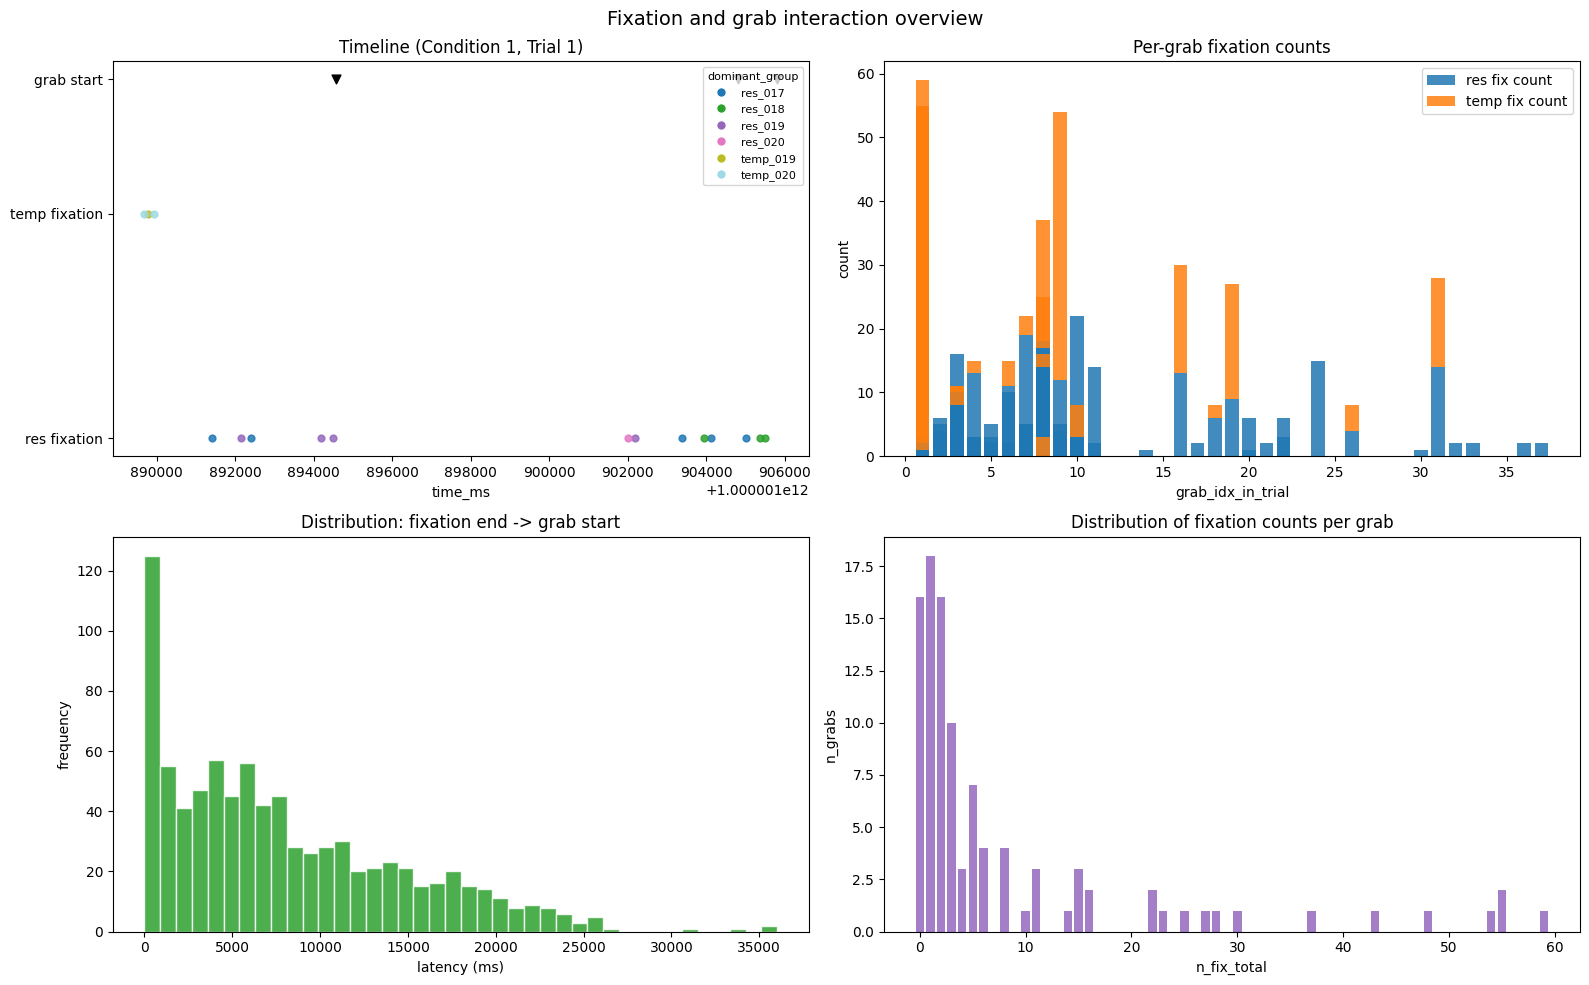

,condition_number,trial_number,grab_idx_in_trial,grabbed_name,n_fix_res,n_fix_temp,n_fix_total
0,1,1,1,brick_2x2_blue_dis_009,5.0,3.0,8.0
1,1,1,9,brick_2x2_green_res_018,5.0,0.0,5.0
2,1,1,10,brick_2x2_pink_res_017,3.0,0.0,3.0
3,1,2,2,brick_2x2_green_res_005,5.0,0.0,5.0
4,1,2,4,brick_2x2_yellow_dis_004,1.0,0.0,1.0
5,1,2,5,brick_2x2_yellow_dis_004,1.0,0.0,1.0
6,1,2,6,brick_2x2_pink_res_007,2.0,0.0,2.0
7,1,3,1,brick_2x4_green_res_067,3.0,3.0,6.0
8,1,3,2,brick_1x3_yellow_res_069,1.0,0.0,1.0
9,1,3,4,brick_2x4_blue_res_068,13.0,2.0,15.0


In [51]:
# --- Visualization: fixation-grab interaction across time ---
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if grab_fixation_summary_df.empty:
    print("No grab summary data available to plot.")
else:
    summary_plot = grab_fixation_summary_df.sort_values(
        ["condition_number", "trial_number", "grab_idx_in_trial"]
    ).reset_index(drop=True)

    events_plot = grab_fixation_events_df.copy()
    if not events_plot.empty:
        events_plot["fixation_to_grab_start_ms"] = (
            events_plot["curr_grab_start_time_ms"] - events_plot["fixation_end_time_ms"]
        )

    # Pick one trial for detailed timeline
    trial_key = (
        summary_plot[["condition_number", "trial_number"]]
        .drop_duplicates()
        .sort_values(["condition_number", "trial_number"])
        .iloc[0]
    )
    cond = trial_key["condition_number"]
    trial = trial_key["trial_number"]

    summary_trial = summary_plot[
        (summary_plot["condition_number"] == cond)
        & (summary_plot["trial_number"] == trial)
    ]
    events_trial = events_plot[
        (events_plot["condition_number"] == cond)
        & (events_plot["trial_number"] == trial)
    ] if not events_plot.empty else events_plot

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1) Timeline: fixation end times colored by dominant_group brick id + grab starts
    ax = axes[0, 0]
    if not events_trial.empty:
        y_map = {"res": 0, "temp": 1}

        groups = sorted(events_trial["dominant_group"].dropna().unique())
        cmap = plt.cm.get_cmap("tab20", max(len(groups), 1))
        color_map = {g: cmap(i) for i, g in enumerate(groups)}

        for g in groups:
            sub = events_trial[events_trial["dominant_group"] == g]
            ax.scatter(
                sub["fixation_end_time_ms"],
                sub["fixation_group_type"].map(y_map),
                c=[color_map[g]],
                s=24,
                alpha=0.85,
                label=g,
            )

        # Compact legend mapping color -> brick group
        handles = [
            Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[g], markersize=7, label=g)
            for g in groups
        ]

        # keep legend readable
        max_legend = 20
        if len(handles) > max_legend:
            handles = handles[:max_legend]
            handles.append(Line2D([0], [0], color="none", label=f"... +{len(groups)-max_legend} more"))
        ax.legend(handles=handles, title="dominant_group", loc="upper right", fontsize=8, title_fontsize=8)

    ax.scatter(
        summary_trial["curr_grab_start_time_ms"],
        [1.6] * len(summary_trial),
        c="black",
        marker="v",
        s=40,
        label="Grab start"
    )
    ax.set_title(f"Timeline (Condition {cond}, Trial {trial})")
    ax.set_xlabel("time_ms")
    ax.set_yticks([0, 1, 1.6])
    ax.set_yticklabels(["res fixation", "temp fixation", "grab start"])

    # 2) Per-grab fixation counts (res vs temp)
    ax = axes[0, 1]
    x = summary_plot["grab_idx_in_trial"].to_numpy()
    ax.bar(x, summary_plot["n_fix_res"], label="res fix count", color="tab:blue", alpha=0.85)
    ax.bar(x, summary_plot["n_fix_temp"], bottom=summary_plot["n_fix_res"], label="temp fix count", color="tab:orange", alpha=0.85)
    ax.set_title("Per-grab fixation counts")
    ax.set_xlabel("grab_idx_in_trial")
    ax.set_ylabel("count")
    ax.legend(loc="best")

    # 3) Distribution: fixation-to-grab latency
    ax = axes[1, 0]
    if not events_plot.empty:
        ax.hist(
            events_plot["fixation_to_grab_start_ms"].dropna(),
            bins=40,
            color="tab:green",
            alpha=0.85,
            edgecolor="white"
        )
        ax.set_title("Distribution: fixation end -> grab start")
        ax.set_xlabel("latency (ms)")
        ax.set_ylabel("frequency")
    else:
        ax.text(0.5, 0.5, "No event rows", ha="center", va="center")
        ax.set_axis_off()

    # 4) Distribution of fixation counts per grab
    ax = axes[1, 1]
    if summary_plot.empty:
        ax.text(0.5, 0.5, "No summary rows", ha="center", va="center")
        ax.set_axis_off()
    else:
        vc = summary_plot["n_fix_total"].value_counts().sort_index()
        ax.bar(vc.index.astype(float), vc.values, color="tab:purple", alpha=0.85)
        ax.set_title("Distribution of fixation counts per grab")
        ax.set_xlabel("n_fix_total")
        ax.set_ylabel("n_grabs")

    fig.suptitle("Fixation and grab interaction overview", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Compact table for quick interpretation
    display_cols = [
        "condition_number", "trial_number", "grab_idx_in_trial", "grabbed_name",
        "n_fix_res", "n_fix_temp", "n_fix_total"
    ]
    display(summary_plot[display_cols].head(20))

C:\Users\experiment\AppData\Local\Temp\ipykernel_15956\2641530959.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(object_names), 1))


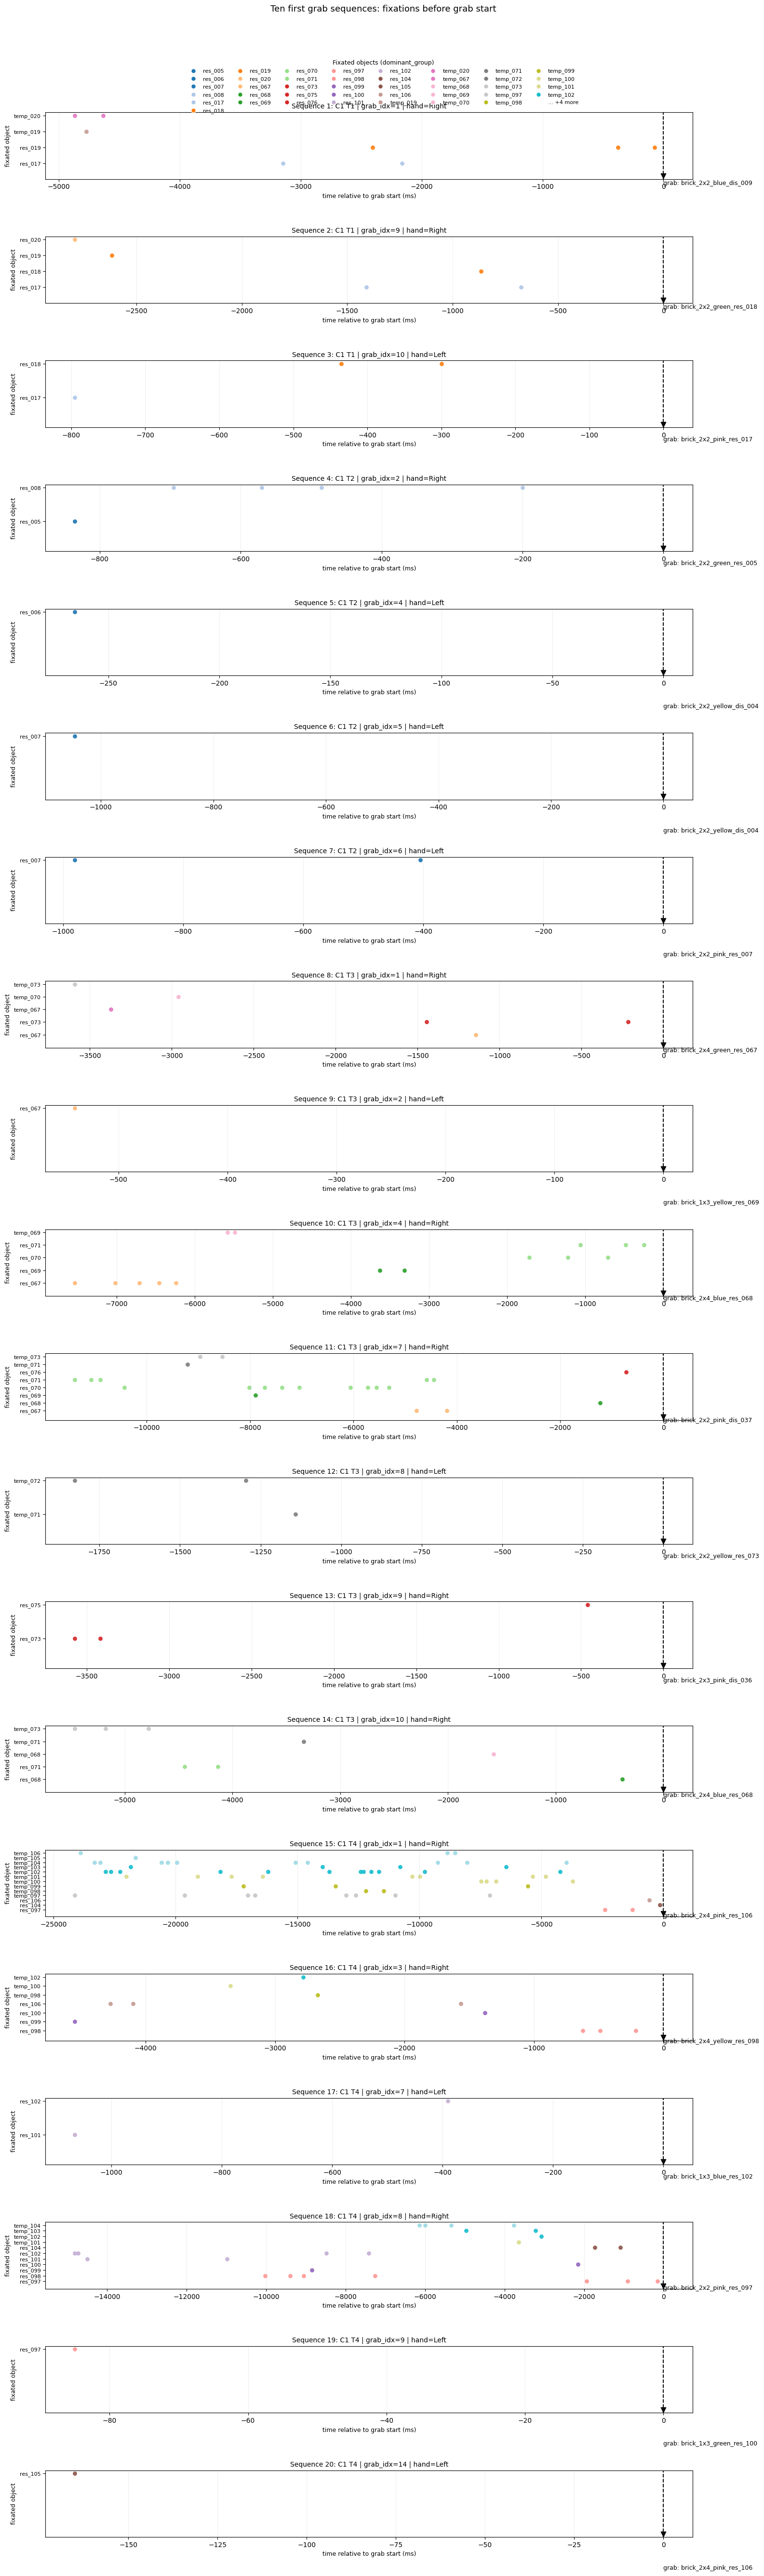

In [57]:
# --- 10 timeline plots: fixation objects before each grab ---
import matplotlib.pyplot as plt

if grab_fixation_summary_df.empty or grab_fixation_events_df.empty:
    print("No grab/fixation data available for 10-sequence timeline plots.")
else:
    key_cols = ["participant_id", "condition_number", "trial_number", "grab_idx_in_trial"]

    # Pick the first 10 grabs in strict chronological order and label them 1..10
    seq_base = (
        grab_fixation_summary_df[grab_fixation_summary_df["n_fix_total"] > 0]
        .sort_values(["curr_grab_start_time_ms", "condition_number", "trial_number", "grab_idx_in_trial"])
        .head(20)
        .copy()
        .reset_index(drop=True)
    )
    seq_base["sequence_order"] = np.arange(1, len(seq_base) + 1)

    if seq_base.empty:
        print("No grabs with fixation events found.")
    else:
        # Build a color map for all objects present across these 10 sequences
        selected_keys = seq_base[key_cols].drop_duplicates()
        events_sel = grab_fixation_events_df.merge(selected_keys, on=key_cols, how="inner")

        object_names = sorted(events_sel["dominant_group"].dropna().unique())
        cmap = plt.cm.get_cmap("tab20", max(len(object_names), 1))
        color_map = {obj: cmap(i) for i, obj in enumerate(object_names)}

        n = len(seq_base)
        fig, axes = plt.subplots(n, 1, figsize=(16, 2.6 * n), sharex=False)
        if n == 1:
            axes = [axes]

        for ax, (_, seq) in zip(axes, seq_base.iterrows()):
            mask = (
                (grab_fixation_events_df["participant_id"] == seq["participant_id"])
                & (grab_fixation_events_df["condition_number"] == seq["condition_number"])
                & (grab_fixation_events_df["trial_number"] == seq["trial_number"])
                & (grab_fixation_events_df["grab_idx_in_trial"] == seq["grab_idx_in_trial"])
            )
            ev = grab_fixation_events_df[mask].copy()

            # Relative timeline in ms: 0 = grab start
            ev["t_rel_ms"] = ev["fixation_end_time_ms"] - seq["curr_grab_start_time_ms"]

            y_labels = sorted(ev["dominant_group"].dropna().unique())
            y_map = {name: i for i, name in enumerate(y_labels)}

            for name in y_labels:
                sub = ev[ev["dominant_group"] == name]
                ax.scatter(
                    sub["t_rel_ms"],
                    [y_map[name]] * len(sub),
                    color=color_map[name],
                    s=28,
                    alpha=0.9,
                    label=name,
                )

            # Mark grab start
            ax.axvline(0, color="black", linestyle="--", linewidth=1.4)
            ax.scatter([0], [-0.8], marker="v", color="black", s=55)
            ax.text(
                0,
                -1.25,
                f"grab: {seq['grabbed_name']}",
                fontsize=9,
                ha="left",
                va="center",
                color="black",
            )

            ax.set_yticks(range(len(y_labels)))
            ax.set_yticklabels(y_labels, fontsize=8)
            ax.set_ylabel("fixated object", fontsize=9)
            ax.set_xlabel("time relative to grab start (ms)", fontsize=9)
            ax.set_title(
                f"Sequence {int(seq['sequence_order'])}: "
                f"C{int(seq['condition_number'])} T{int(seq['trial_number'])} | "
                f"grab_idx={int(seq['grab_idx_in_trial'])} | hand={seq['hand']}",
                fontsize=10,
            )
            ax.grid(axis="x", alpha=0.2)

        # Global legend: all fixated objects shown in the 10 sequences
        handles = [
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[obj], markersize=7, label=obj)
            for obj in object_names
        ]
        max_legend = 40
        if len(handles) > max_legend:
            handles = handles[:max_legend] + [plt.Line2D([0], [0], color="none", label=f"... +{len(object_names)-max_legend} more")]

        fig.legend(
            handles=handles,
            loc="upper center",
            ncol=8,
            fontsize=8,
            title="Fixated objects (dominant_group)",
            title_fontsize=9,
            frameon=False,
            bbox_to_anchor=(0.5, 1.01),
        )

        fig.suptitle("Ten first grab sequences: fixations before grab start", fontsize=13, y=1.03)
        plt.tight_layout()
        plt.show()